## What is the most optimal skill to learn for Data Analysts?

## Import Libraries and Data
Import the libraries, data and change the job_posted_date to a datetime type.

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\LLP\anaconda3\envs\Python_Project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Clean Data

This section prepares the dataset for analysis by filtering only **Data Analyst** jobs located in the **United States**. It removes records with missing salary information, then expands the `job_skills` column using the `explode()` method so that each skill appears in its own row. This makes it easier to analyze individual skills and their relationship with salary.

In [6]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_Exploded = df_DA_US.explode('job_skills')
df_DA_US_Exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


## Calculate the Percentage of Job Postings by Skill

This section groups the data by individual skills to calculate both the number of job postings and the median salary for each skill. It then computes the percentage of Data Analyst job postings that require each skill, renames the columns for clarity, and removes any skills with no associated job postings. The resulting dataset is used to compare skill demand with salary in the following analysis.


In [7]:
# using df_DA find the count of skills and also the median salary for each skill
df_DA_skills = df_DA_US_Exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
DA_job_count = len(df_DA_US)  # Find count of Data Analyst jobs in US with salary info
df_DA_skills['skill_percentage'] = (df_DA_skills['skill_count'] / DA_job_count) * 100
df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0]
df_DA_skills

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


## Median Salary vs. Percent Skill Demand

Filters Data Analyst skills based on a minimum demand threshold (`skill_limit`) to focus on commonly requested skills. The filtered dataset is then used to compare median salary with the percentage of job postings requiring each skill.

In [9]:
skill_limit = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percentage'] > skill_limit]

Creating a scatter plot to visualize the relationship between the percentage of Data Analyst jobs that require specific skills and the median salary for those skills.

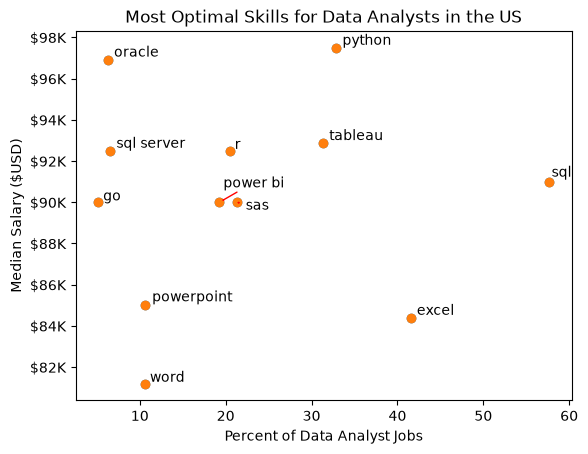

In [21]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_high_demand['skill_percentage'], df_DA_skills_high_demand['median_salary'])
plt.scatter(df_DA_skills_high_demand['skill_percentage'], df_DA_skills_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the US')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, poss: f'${int(x/1000)}K'))  # Format y-axis as currency
# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.show()

## Bonus: Coloring by Technology

This section adds technology categories to the skill analysis by assigning colors based on different technology types. It cleans the technology mapping data by removing duplicate and missing values, then combines multiple entries into a single dictionary. For skills that appear under multiple technology categories, it keeps only unique category values to create a cleaner mapping for visualization.

In [34]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


In [27]:
technology_dict

{'analyst_tools': ['sheets',
  'powerbi',
  'ms access',
  'outlook',
  'sas',
  'tableau',
  'powerpoint',
  'datarobot',
  'looker',
  'sharepoint',
  'msaccess',
  'spss',
  'splunk',
  'nuix',
  'esquisse',
  'alteryx',
  'power bi',
  'word',
  'sap',
  'dax',
  'cognos',
  'microstrategy',
  'ssrs',
  'excel',
  'qlik',
  'visio',
  'ssis',
  'spreadsheet'],
 'programming': ['powershell',
  'solidity',
  'crystal',
  'delphi',
  'javascript',
  'rust',
  'mongodb',
  'kotlin',
  'haskell',
  'php',
  'mongo',
  'sas',
  'css',
  'go',
  'lua',
  'golang',
  'typescript',
  'elixir',
  'scala',
  'cobol',
  'html',
  'c',
  'erlang',
  'shell',
  'ocaml',
  'visualbasic',
  'sql',
  'apl',
  'bash',
  'sass',
  'assembly',
  'vb.net',
  'objective-c',
  'ruby',
  'pascal',
  'java',
  'fortran',
  'julia',
  'swift',
  'matlab',
  'c#',
  'vba',
  't-sql',
  'clojure',
  'no-sql',
  'groovy',
  'c++',
  'f#',
  'visual basic',
  'dart',
  'python',
  'perl',
  'nosql',
  'lisp',
 

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [28]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sheets
0,analyst_tools,powerbi
0,analyst_tools,ms access
0,analyst_tools,outlook
0,analyst_tools,sas
...,...,...
9,sync,unify
9,sync,rocketchat
9,sync,slack
9,sync,wire


Merges two DataFrames, df_DA_skills and df_technology, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame df_DA_skills_tech.

In [29]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_percentage,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,100000.0,0.022989,libraries,theano
170,1,65000.0,0.022989,programming,typescript
171,1,147500.0,0.022989,cloud,vmware
172,1,65000.0,0.022989,webframeworks,vue


Filters df_DA_skills_tech to select rows where the 'percent' column exceeds a specified threshold, storing the result in df_DA_skills_tech_high_demand.

In [31]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percentage'] > skill_limit]

Plot the results in a scatter plot, coloring the points based on the 'technology' column.

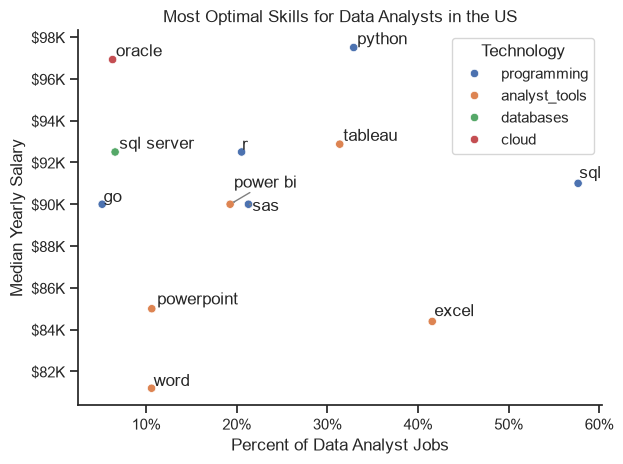

In [33]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skill_percentage',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()